<a href="https://colab.research.google.com/github/sathar1919/DS-Projects/blob/main/Regularized_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regularized Linear Regression**

We will use the Diabetes dataset available directly from Scikit-learn.

We will compare:

Linear Regression

Ridge Regression

Lasso Regression

**Regularization** is a technique used in machine learning to **prevent overfitting**

otherwise causes models to **perform poorly on unseen data**.

By **adding a penalty** for complexity, regularization encourages simpler and more generalizable models.

**Lasso Regression**

stands for **Least Absolute Shrinkage and Selection Operator Regression.**

It is a linear regression algorithm with **L1 regularization**.

It is mainly used to **reduce overfitting and perform feature selection.**

Lasso adds a **penalty to the regression cost function based on the absolute value of coefficients.**

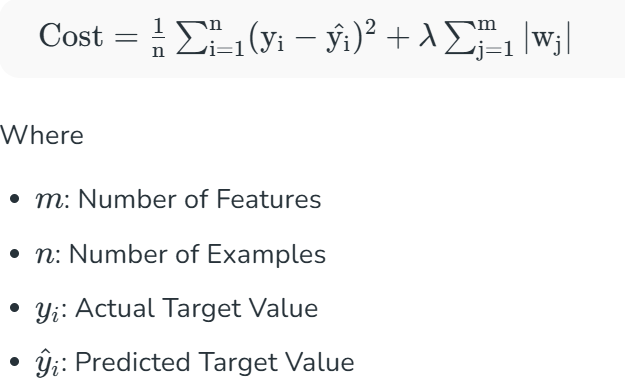

**Ridge Regression**

A regression model that uses the **L2 regularization technique** is called Ridge regression.

adds the **squared magnitude of the coefficient as a penalty term to the loss function(L)**.

handles **multicollinearity by shrinking the coefficients of correlated features, reducing their variance and preventing any single feature from dominating the model**.

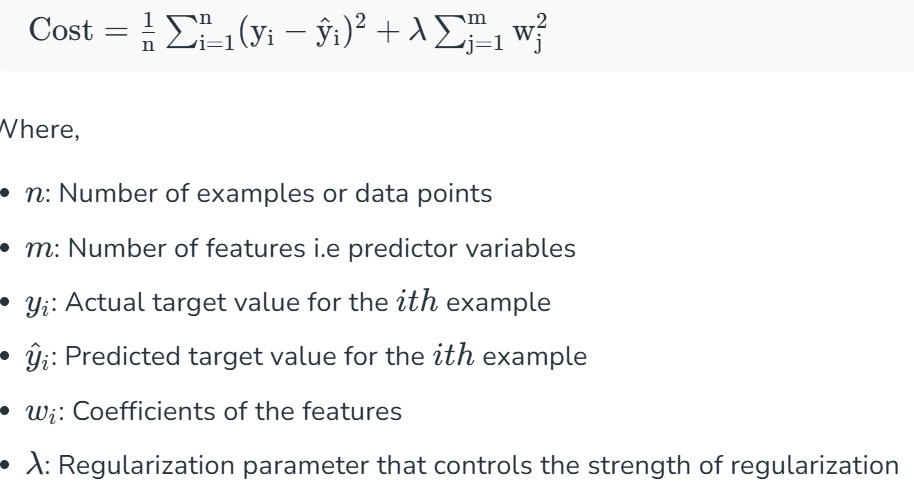

In [1]:
# ============================================
# 2. REGULARIZED LINEAR REGRESSION
# ============================================

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

In [2]:
#load data set
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data,columns=diabetes.feature_names)
y = diabetes.target
print("Features:")
print(X.head())
print("\nTarget:")
print(y[:5])

Features:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

Target:
[151.  75. 141. 206. 135.]


In [3]:
#Train and Spilt Data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled,y_train)
y_pred_linear = linear_model.predict(X_test_scaled)

In [8]:
print("Linear Regression")
print("MAE:",mean_absolute_error(y_test, y_pred_linear))
print("MSE:",mean_squared_error(y_test, y_pred_linear))
print("R2 Score:",r2_score(y_test, y_pred_linear))

Linear Regression
MAE: 42.79409467959994
MSE: 2900.1936284934823
R2 Score: 0.45260276297191926


In [9]:
#Ridge Regression
#Ridge uses L2 regularization.
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

In [10]:
print("Ridge Regression")
print("MAE:",mean_absolute_error(y_test, y_pred_ridge))
print("MSE:",mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:",r2_score(y_test, y_pred_ridge))

Ridge Regression
MAE: 42.81199941834888
MSE: 2892.0145657501726
R2 Score: 0.45414652070698225


In [12]:
#Lasso Regression
#Lasso uses L1 regularization.
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_scaled,y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

In [13]:
print("Lasso Regression")
print("MAE:",mean_absolute_error(y_test, y_pred_lasso))
print("MSE:",mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:",r2_score(y_test, y_pred_lasso))

Lasso Regression
MAE: 42.79501773801213
MSE: 2898.368019282879
R2 Score: 0.4529473377023646


In [14]:
#campring All models
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

results

,Model,MAE,MSE,R2 Score
0,Linear Regression,42.794095,2900.193628,0.452603
1,Ridge Regression,42.811999,2892.014566,0.454147
2,Lasso Regression,42.795018,2898.368019,0.452947
